<a href="https://colab.research.google.com/github/rikesh28/Credit_Card_Fraud_Detection/blob/main/notebooks/4)%20baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, precision_recall_curve, roc_auc_score,
                             roc_curve, precision_score, recall_score, f1_score)

import warnings
warnings.filterwarnings('ignore')

In [3]:
X_train = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/X_train.csv')
X_test = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/X_test.csv')

y_train = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/y_train.csv')
y_test = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/y_test.csv')

In [4]:
print(f'X_train shape: {X_train.shape}')
print(f'y_train fraud rate: {y_train['isFraud'].mean() * 100:.2f}%')
print(f'X_test shape: {X_test.shape}')
print(f'y_test fraud rate: {y_test['isFraud'].mean() * 100:.2f}%')

X_train shape: (472432, 434)
y_train fraud rate: 3.51%
X_test shape: (118108, 434)
y_test fraud rate: 3.44%


In [ ]:
# start with plain logistic regression - no class balancing
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
y_pred_prob = lr_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

# 8% recall is terrible - it's basically just predicting "not fraud" for everything
# because 96.5% of the data is legitimate. need to address class imbalance.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_ylabel('True')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_xticklabels(['Legit', 'Fraud'])
axes[0, 0].set_yticklabels(['Legit', 'Fraud'])

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)
axes[0, 1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].set_xlabel('FPR')
axes[0, 1].set_ylabel('TPR')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
axes[1, 0].plot(recall, precision, lw=2)
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].axhline(y=y_test['isFraud'].mean(), color='r', linestyle='--',
                    label=f'Baseline ({y_test["isFraud"].mean():.3f})')
axes[1, 0].legend()

# probability distribution: model barely assigns any probability to fraud
axes[1, 1].hist(y_pred_prob[y_test['isFraud'] == 0], bins=50, alpha=0.6, label='Legit', color='green')
axes[1, 1].hist(y_pred_prob[y_test['isFraud'] == 1], bins=50, alpha=0.6, label='Fraud', color='red')
axes[1, 1].set_title('Predicted Probability Distribution')
axes[1, 1].legend()
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')

===== Top 20 Most important Features ======
             feature  coefficient
33                D8    -0.004413
37               D12     0.002410
316             V267    -0.002230
25               C13    -0.002057
30                D4    -0.002032
213             V164    -0.001908
395            id_09     0.001795
396            id_10     0.001787
360             V311    -0.001785
34                D9     0.001775
411            id_33    -0.001682
384             V335     0.001623
27                D1    -0.001576
420  Transaction_day     0.001570
317             V268    -0.001510
14                C2     0.001490
368             V319    -0.001445
326             V277     0.001394
380             V331    -0.001341
323             V274     0.001295


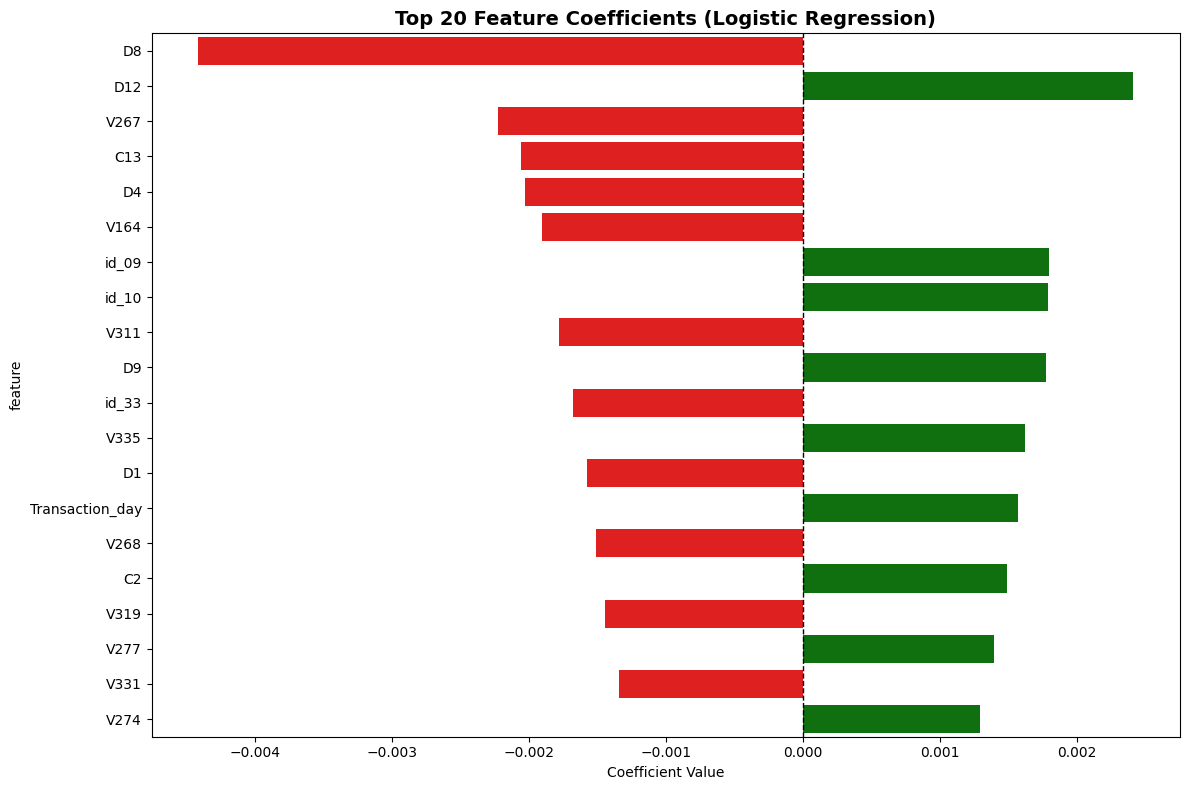

In [7]:
# Feature Importance (absolute coefficient value)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_[0]
}).sort_values(by = 'coefficient', key = abs, ascending=False)

print('===== Top 20 Most important Features ======')
print(feature_importance.head(20))

# Visualize
plt.figure(figsize=(12, 8))
top_20 = feature_importance.head(20)
colors = ['red' if x < 0 else 'green' for x in top_20['coefficient']]
sns.barplot(data=top_20, y='feature', x='coefficient', palette=colors)
plt.title('Top 20 Feature Coefficients (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:
# The class imbalance problem is clear: 96.5% legitimate, 3.5% fraud.
# The model learned "just say not fraud" because that's right 96.5% of the time.
# But it catches only 8% of actual fraud - completely useless.

print(f'Training class distribution:')
print(y_train['isFraud'].value_counts())
print(f'\nFraud rate: {y_train["isFraud"].mean()*100:.2f}%')
print(f'Imbalance ratio: 1:{int(1/y_train["isFraud"].mean())}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
y_train['isFraud'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)

y_train['isFraud'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                        colors=['green', 'red'], labels=['Legit', 'Fraud'])
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Try class_weight='balanced' - this tells sklearn to weight the fraud class
# inversely proportional to its frequency

lr_model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model_balanced.fit(X_train, y_train)
print('Done')

In [21]:
y_pred_balanced = lr_model_balanced.predict(X_test)
y_pred_prob_balanced = lr_model_balanced.predict_proba(X_test)[:,1]
print('\nBalanced Model Performance')
print(classification_report(y_test, y_pred_balanced, target_names=['Legitimate', 'Fraud']))


Balanced Model Performance
              precision    recall  f1-score   support

  Legitimate       0.99      0.78      0.87    114044
       Fraud       0.10      0.67      0.17      4064

    accuracy                           0.78    118108
   macro avg       0.54      0.73      0.52    118108
weighted avg       0.95      0.78      0.85    118108



In [ ]:
# big recall jump: 8% -> 67%. tradeoff is precision dropped (more false alarms).
# for fraud detection, catching fraud matters more than avoiding false alarms.
print("Baseline vs Balanced:")
print(f"{'Metric':<20} {'Baseline':<15} {'Balanced':<15}")
print("-" * 50)
print(f"{'Precision':<20} {precision_score(y_test, y_pred):<15.4f} {precision_score(y_test, y_pred_balanced):<15.4f}")
print(f"{'Recall':<20} {recall_score(y_test, y_pred):<15.4f} {recall_score(y_test, y_pred_balanced):<15.4f}")
print(f"{'F1-Score':<20} {f1_score(y_test, y_pred):<15.4f} {f1_score(y_test, y_pred_balanced):<15.4f}")
print(f"{'ROC-AUC':<20} {roc_auc_score(y_test, y_pred_prob):<15.4f} {roc_auc_score(y_test, y_pred_prob_balanced):<15.4f}")

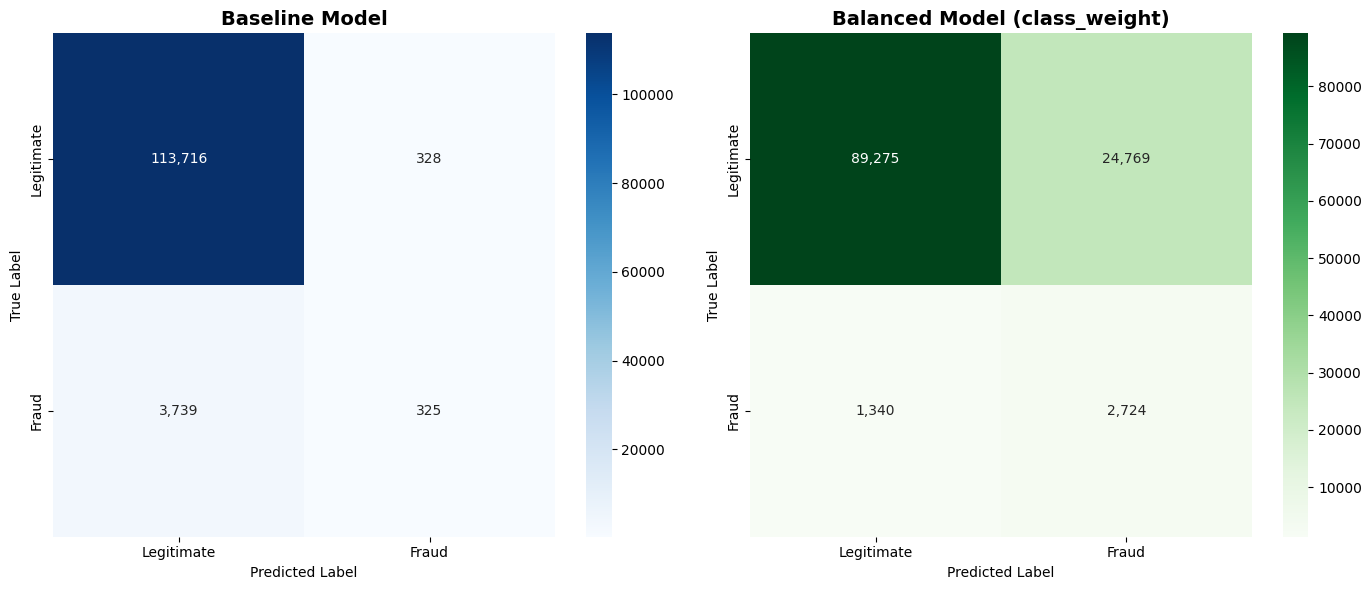


Fraud Detection Rate (Recall):
  Baseline: 8.00%
  Balanced: 67.03%
  Improvement: +59.03%


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Baseline confusion matrix
cm_baseline = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_baseline, annot=True, fmt=',d', cmap='Blues', ax=axes[0])
axes[0].set_title('Baseline Model', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0].set_yticklabels(['Legitimate', 'Fraud'])

# Balanced confusion matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm_balanced, annot=True, fmt=',d', cmap='Greens', ax=axes[1])
axes[1].set_title('Balanced Model (class_weight)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].set_xticklabels(['Legitimate', 'Fraud'])
axes[1].set_yticklabels(['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

# Calculate recall improvement
baseline_recall = cm_baseline[1,1] / (cm_baseline[1,0] + cm_baseline[1,1])
balanced_recall = cm_balanced[1,1] / (cm_balanced[1,0] + cm_balanced[1,1])

print(f"\nFraud Detection Rate (Recall):")
print(f"  Baseline: {baseline_recall*100:.2f}%")
print(f"  Balanced: {balanced_recall*100:.2f}%")
print(f"  Improvement: +{(balanced_recall - baseline_recall)*100:.2f}%")

## Random Forest

Linear model can only go so far. Trying a tree-based model to capture non-linear patterns.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=100,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)
print('Done')

In [30]:
y_pred_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)[:,1]

print('\nRandom Forest Model Performance')
print(classification_report(y_test, y_pred_rf, target_names = ['Legitimate', 'Fraud']))

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s



Random Forest Model Performance
              precision    recall  f1-score   support

  Legitimate       0.99      0.87      0.93    114044
       Fraud       0.17      0.70      0.27      4064

    accuracy                           0.87    118108
   macro avg       0.58      0.79      0.60    118108
weighted avg       0.96      0.87      0.91    118108



[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished


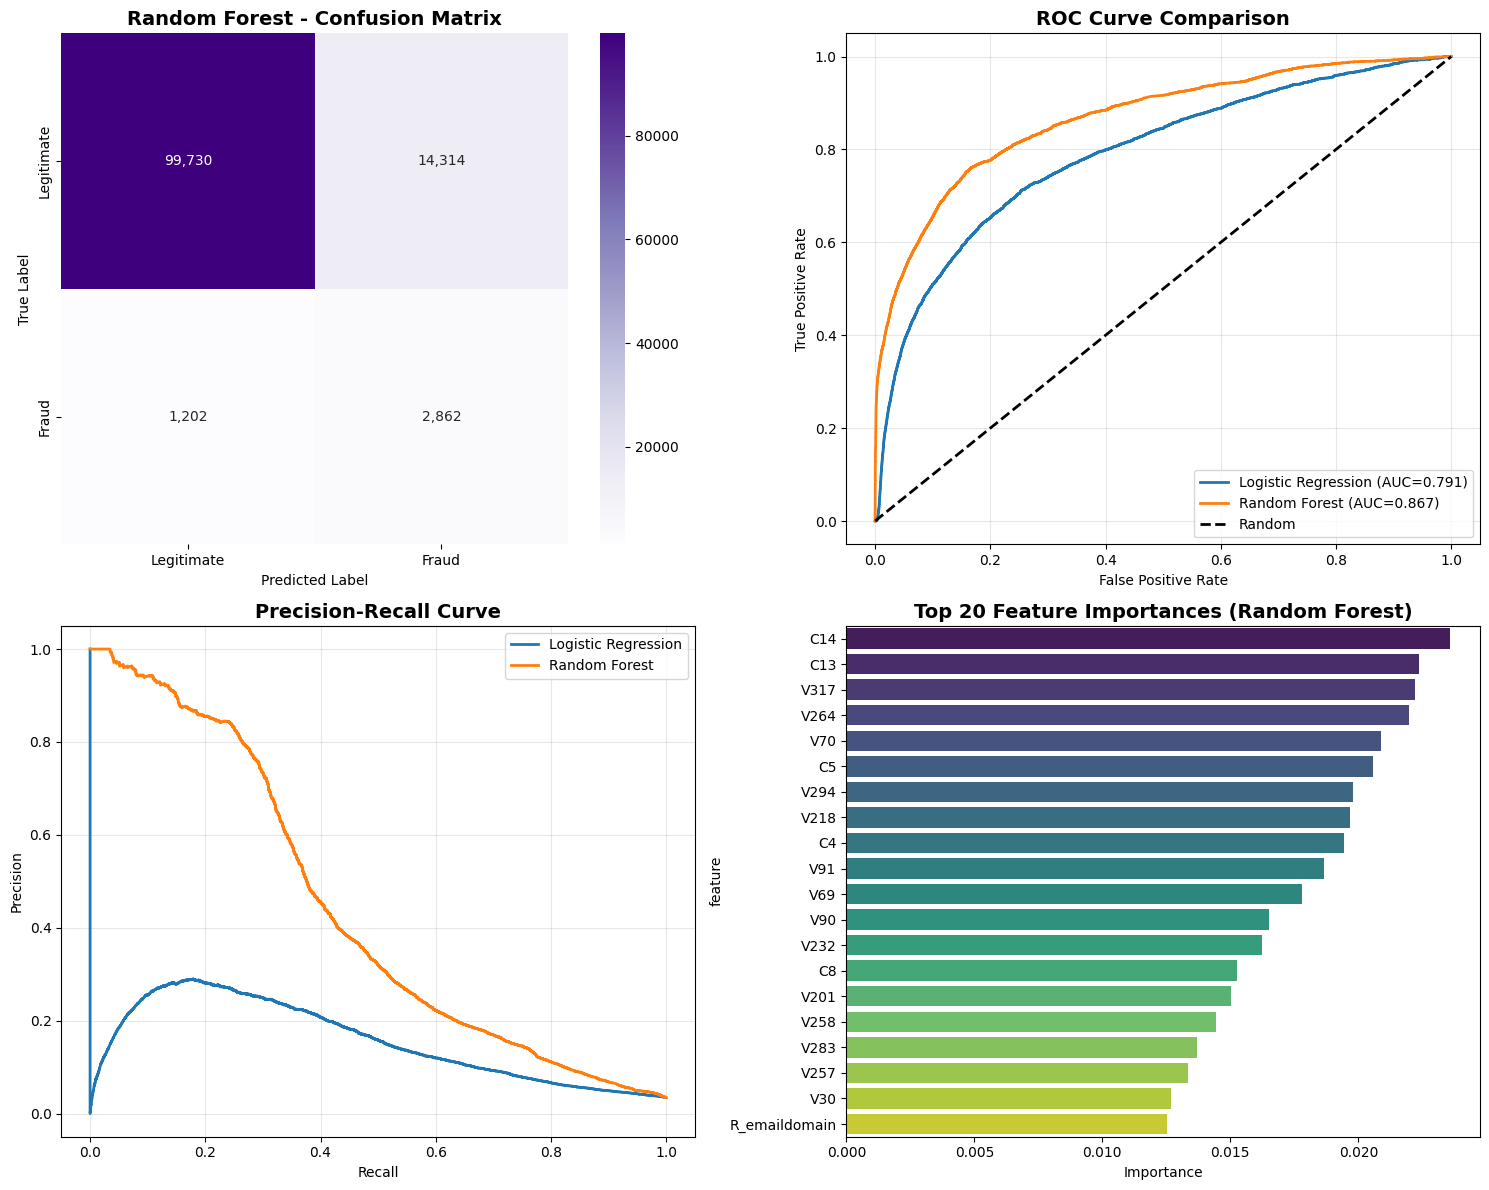

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt=',d', cmap='Purples', ax=axes[0,0])
axes[0,0].set_title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')
axes[0,0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0,0].set_yticklabels(['Legitimate', 'Fraud'])

# 2. ROC Curve Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_balanced)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)

axes[0,1].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_pred_prob_balanced):.3f})', lw=2)
axes[0,1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_pred_prob_rf):.3f})', lw=2)
axes[0,1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve Comparison
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_prob_balanced)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_prob_rf)

axes[1,0].plot(recall_lr, precision_lr, label='Logistic Regression', lw=2)
axes[1,0].plot(recall_rf, precision_rf, label='Random Forest', lw=2)
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Feature Importance (Random Forest)
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

sns.barplot(data=feature_importance_rf, y='feature', x='importance',
            ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Importance')

plt.tight_layout()
plt.show()


MODEL COMPARISON
                            Model  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression (Baseline)   0.497703  0.079970  0.137799  0.771597
1  Logistic Regression (Balanced)   0.099080  0.670276  0.172640  0.791146
2                   Random Forest   0.166628  0.704232  0.269492  0.867350


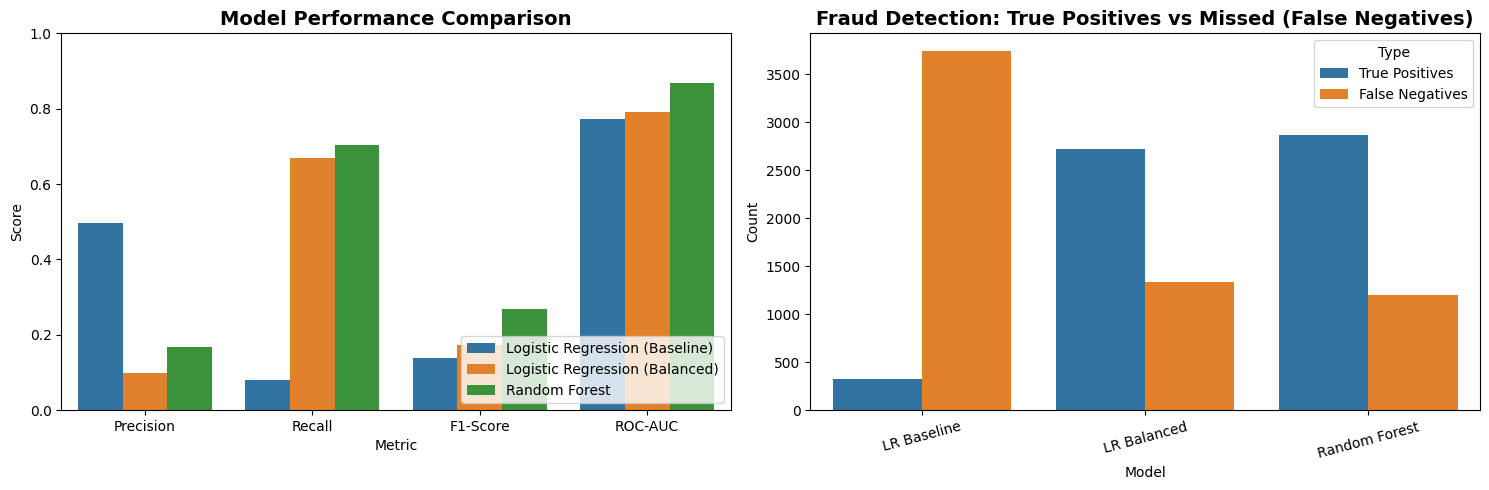


WINNER: Random Forest catches the most fraud!


In [35]:
# Model Comparison
print('\nMODEL COMPARISON')
models_comparison = pd.DataFrame({
    'Model':['Logistic Regression (Baseline)',
             'Logistic Regression (Balanced)',
             'Random Forest'],
    'Precision': [precision_score(y_test, y_pred),
                  precision_score(y_test, y_pred_balanced),
                  precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred),
               recall_score(y_test, y_pred_balanced),
               recall_score(y_test, y_pred_rf)],
    'F1-Score': [f1_score(y_test, y_pred),
                 f1_score(y_test, y_pred_balanced),
                 f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_pred_prob),
                roc_auc_score(y_test, y_pred_prob_balanced),
                roc_auc_score(y_test, y_pred_prob_rf)]
})

print(models_comparison)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Metrics comparison
metrics_melted = models_comparison.melt(id_vars='Model',
                                        value_vars=['Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
                                        var_name='Metric',
                                        value_name='Score')

sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Model', ax=axes[0])
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right')
axes[0].set_ylim([0, 1])

# Confusion matrices side by side (just counts)
cm_data = pd.DataFrame({
    'Model': ['LR Baseline', 'LR Balanced', 'Random Forest'],
    'True Positives': [cm_baseline[1,1], cm_balanced[1,1], cm_rf[1,1]],
    'False Negatives': [cm_baseline[1,0], cm_balanced[1,0], cm_rf[1,0]]
})

cm_melted = cm_data.melt(id_vars='Model', var_name='Type', value_name='Count')
sns.barplot(data=cm_melted, x='Model', y='Count', hue='Type', ax=axes[1])
axes[1].set_title('Fraud Detection: True Positives vs Missed (False Negatives)',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\nWINNER: Random Forest catches the most fraud!")

In [37]:
import pickle
print('Saving Random Forest Model')
model_path = '/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/3) Models/random_forest_model.pkl'
with open(model_path, 'wb') as f:
  pickle.dump(rf_model, f)

print(f'Model saved to: {model_path}')

# Saving Feature importance
feature_importance_rf.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/3) Models/feature_importance_rf.csv', index = False)
print('Feature Importance Saved')

# Saving performance metrics
models_comparison.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/3) Models/models_comparison.csv', index = False)
print('Model Comparison Saved')
print('All models and results saved.')

Saving Random Forest Model
Model saved to: /content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/3) Models/random_forest_model.pkl
Feature Importance Saved
Model Comparison Saved
All models and results saved.


## Baseline results

- Plain logistic regression is useless for imbalanced data (8% recall).
- `class_weight='balanced'` fixes recall (67%) but tanks precision (10%).
- Random forest is the best baseline: 70% recall, 0.87 ROC-AUC. Tree models handle the non-linear interactions between features much better.
- Top features: C14, C13, V317, V264 - all anonymized Vesta features. Hard to interpret but clearly useful.

Next: XGBoost, which should do even better with gradient boosting.